In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ngc6523/raw-prices/adjusted_close_prices.csv


In [31]:
!pip install lifelines

# Survival Analysis for 4 ETFs

This notebook studies three different survival-analysis event definitions for 4 ETFs:

1. **ETF closure**
2. **Time to recover to previous maximum**
3. **First time actual loss exceeds the Value-at-Risk (VaR) estimate**

Main tools:
- **Kaplan–Meier estimator** for the survival function
- **Cox proportional hazards regression** as the main model


Important note:
- The **closure** event is hard to identify from price data alone, so we use an operational definition based on the price series ending before the overall dataset end.
- For the **recovery** and **VaR exceedance** analyses, we create multiple episodes per ETF so that Cox regression has enough observations.

In [32]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter, NelsonAalenFitter
from lifelines.exceptions import ConvergenceError
from lifelines.statistics import logrank_test, multivariate_logrank_test

from sklearn.preprocessing import StandardScaler

## Load the ETF price data

We:
- read the CSV,
- convert the date column,
- detect ETF columns,
- keep the first 4 ETF columns,
- sort by date.

In [33]:
file_path = '/kaggle/input/datasets/ngc6523/raw-prices/adjusted_close_prices.csv'

df_raw = pd.read_csv(file_path)
print("Raw shape:", df_raw.shape)
print(df_raw.head())
print(df_raw.columns.tolist())

Raw shape: (2766, 5)
         Date         SPY        QQQ         GLD         VOO
0  2015-01-02  170.124969  94.665085  114.080002  155.227417
1  2015-01-05  167.052597  93.276459  115.800003  152.500290
2  2015-01-06  165.479172  92.025764  117.120003  151.000732
3  2015-01-07  167.541214  93.212082  116.430000  152.887512
4  2015-01-08  170.514191  94.996155  115.940002  155.573578
['Date', 'SPY', 'QQQ', 'GLD', 'VOO']


In [34]:
# Try to identify the date column
possible_date_cols = [c for c in df_raw.columns if c.lower() in ['date', 'datetime', 'timestamp']]
if len(possible_date_cols) == 0:
    raise ValueError("Could not find a date column. Please rename your date column to 'Date' or edit the notebook.")
date_col = possible_date_cols[0]

df_raw[date_col] = pd.to_datetime(df_raw[date_col])
df_raw = df_raw.sort_values(date_col).reset_index(drop=True)

# Detect numeric ETF columns
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
etf_cols = [c for c in numeric_cols if c != date_col]

if len(etf_cols) < 4:
    raise ValueError(f"Need at least 4 numeric ETF columns, but found only {len(etf_cols)}.")

etf_cols = etf_cols[:4]
print("Using ETF columns:", etf_cols)

prices = df_raw[[date_col] + etf_cols].copy()
prices.head()

Using ETF columns: ['SPY', 'QQQ', 'GLD', 'VOO']


,Date,SPY,QQQ,GLD,VOO
0,2015-01-02,170.124969,94.665085,114.080002,155.227417
1,2015-01-05,167.052597,93.276459,115.800003,152.500290
2,2015-01-06,165.479172,92.025764,117.120003,151.000732
3,2015-01-07,167.541214,93.212082,116.430000,152.887512
4,2015-01-08,170.514191,94.996155,115.940002,155.573578


## Basic cleaning

We keep positive prices only and inspect missingness.

In [35]:
for c in etf_cols:
    prices.loc[prices[c] <= 0, c] = np.nan

print(prices.isna().sum())
prices.tail()
# Reshape into long format
long_prices = prices.melt(id_vars=[date_col], value_vars=etf_cols,
                          var_name='ETF', value_name='AdjClose')

long_prices = long_prices.sort_values(['ETF', date_col]).reset_index(drop=True)
long_prices.head(10)

Date    0
SPY     0
QQQ     0
GLD     0
VOO     0
dtype: int64


,Date,ETF,AdjClose
0,2015-01-02,GLD,114.080002
1,2015-01-05,GLD,115.800003
2,2015-01-06,GLD,117.120003
3,2015-01-07,GLD,116.430000
4,2015-01-08,GLD,115.940002
5,2015-01-09,GLD,117.260002
6,2015-01-12,GLD,118.559998
7,2015-01-13,GLD,118.160004
8,2015-01-14,GLD,117.970001
9,2015-01-15,GLD,120.940002


In [36]:
# ============================================
# Helper functions for KM, hazard, and forest
# ============================================

def add_median_lines_single(kmf, color='red', label_prefix='Median'):
    """
    Add median survival reference lines for a single KM curve.
    """
    median_t = kmf.median_survival_time_
    plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    if np.isfinite(median_t):
        plt.axvline(median_t, color=color, linestyle='--', linewidth=1.5,
                    label=f'{label_prefix} = {median_t:.1f}')
    return median_t


def plot_grouped_km_with_medians(df, duration_col, event_col, group_col, title, xlabel, ylabel):
    """
    Plot KM curves by group and add median survival reference lines.
    """
    plt.figure(figsize=(10, 6))
    plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Survival = 0.5')

    median_dict = {}
    for group in sorted(df[group_col].dropna().unique()):
        sub = df[df[group_col] == group].copy()
        if len(sub) == 0:
            continue

        kmf = KaplanMeierFitter()
        kmf.fit(sub[duration_col], event_observed=sub[event_col], label=str(group))
        ax = kmf.plot_survival_function(ci_show=True)

        median_t = kmf.median_survival_time_
        median_dict[group] = median_t

        if np.isfinite(median_t):
            plt.axvline(median_t, linestyle='--', linewidth=1.2)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.show()

    print("Median survival times:")
    for k, v in median_dict.items():
        if np.isfinite(v):
            print(f"  {k}: {v:.2f}")
        else:
            print(f"  {k}: not reached (survival never fell below 0.5)")


def plot_single_km_with_median(df, duration_col, event_col, label, title, xlabel, ylabel):
    """
    Plot a single KM curve with median survival reference lines.
    """
    kmf = KaplanMeierFitter()
    kmf.fit(df[duration_col], event_observed=df[event_col], label=label)

    plt.figure(figsize=(8, 5))
    kmf.plot_survival_function(ci_show=True)
    median_t = add_median_lines_single(kmf, color='red', label_prefix='Median survival time')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.show()

    if np.isfinite(median_t):
        print(f"Median survival time: {median_t:.2f}")
    else:
        print("Median survival time not reached (curve never dropped below 0.5).")


def plot_hazard_and_cumhaz_by_group(df, duration_col, event_col, group_col, title_prefix, bandwidth=10):
    """
    Plot cumulative hazard and smoothed hazard by group using Nelson-Aalen.
    """
    # Cumulative hazard
    plt.figure(figsize=(10, 6))
    for group in sorted(df[group_col].dropna().unique()):
        sub = df[df[group_col] == group].copy()
        if len(sub) == 0:
            continue

        naf = NelsonAalenFitter()
        naf.fit(sub[duration_col], event_observed=sub[event_col], label=str(group))
        naf.plot_cumulative_hazard()

    plt.title(f'{title_prefix}: Cumulative Hazard')
    plt.xlabel('Time')
    plt.ylabel('Cumulative hazard')
    plt.grid(True)
    plt.show()

    # Smoothed hazard
    plt.figure(figsize=(10, 6))
    any_plotted = False

    for group in sorted(df[group_col].dropna().unique()):
        sub = df[df[group_col] == group].copy()
        if len(sub) == 0 or sub[event_col].sum() < 2:
            continue

        naf = NelsonAalenFitter()
        naf.fit(sub[duration_col], event_observed=sub[event_col], label=str(group))

        try:
            hz = naf.smoothed_hazard_(bandwidth=bandwidth)
            plt.plot(hz.index, hz.values, label=str(group))
            any_plotted = True
        except Exception as e:
            print(f"Could not compute smoothed hazard for {group}: {e}")

    if any_plotted:
        plt.title(f'{title_prefix}: Smoothed Hazard')
        plt.xlabel('Time')
        plt.ylabel('Hazard')
        plt.grid(True)
        plt.legend()
        plt.show()
    else:
        print(f"No stable smoothed hazard curves available for {title_prefix}.")


def run_multigroup_logrank(df, duration_col, event_col, group_col, title='Log-rank test'):
    """
    Run multivariate log-rank test across groups.
    """
    test_df = df[[duration_col, event_col, group_col]].dropna().copy()

    if test_df[group_col].nunique() < 2:
        print(f"{title}: not enough groups.")
        return None

    if test_df[event_col].sum() == 0:
        print(f"{title}: no observed events, so log-rank is not informative.")
        return None

    result = multivariate_logrank_test(
        event_durations=test_df[duration_col],
        groups=test_df[group_col],
        event_observed=test_df[event_col]
    )

    print(f'=== {title} ===')
    print(result.summary)
    return result


def make_forest_plot_from_cph(cph, title='Forest Plot of Adjusted Hazard Ratios'):
    """
    Create a forest plot from a fitted CoxPHFitter model.
    """
    s = cph.summary.copy()

    forest_df = pd.DataFrame({
        'variable': s.index,
        'ahr': s['exp(coef)'],
        'lower': s['exp(coef) lower 95%'],
        'upper': s['exp(coef) upper 95%'],
        'p': s['p']
    }).sort_values('ahr')

    plt.figure(figsize=(8, max(4, 0.6 * len(forest_df))))
    y = np.arange(len(forest_df))

    plt.errorbar(
        forest_df['ahr'],
        y,
        xerr=[forest_df['ahr'] - forest_df['lower'],
              forest_df['upper'] - forest_df['ahr']],
        fmt='o',
        capsize=4
    )

    plt.axvline(1.0, linestyle='--', linewidth=1)
    plt.yticks(y, forest_df['variable'])
    plt.xlabel('Adjusted Hazard Ratio (AHR)')
    plt.title(title)
    plt.grid(True, axis='x')
    plt.show()

    return forest_df

## Compute log returns and rolling covariates

These features will later be used in the Cox model:
- log return
- loss = negative log return
- rolling volatility
- rolling mean return
- rolling VaR

In [37]:
ROLL_VOL = 21          # about 1 trading month
VAR_WINDOW = 63        # about 3 trading months
VAR_ALPHA = 0.95       # 95% VaR

def add_return_features(group):
    group = group.sort_values(date_col).copy()
    group['log_return'] = np.log(group['AdjClose'] / group['AdjClose'].shift(1))
    group['loss'] = -group['log_return']
    group['roll_vol_21'] = group['log_return'].rolling(ROLL_VOL).std()
    group['roll_mean_21'] = group['log_return'].rolling(ROLL_VOL).mean()
    
    # Historical rolling VaR for loss
    # VaR at 95% means the 95th percentile of losses
    group['VaR_95'] = group['loss'].rolling(VAR_WINDOW).quantile(VAR_ALPHA)
    return group

long_feat = long_prices.groupby('ETF', group_keys=False).apply(add_return_features).reset_index(drop=True)
long_feat.head(10)

,Date,ETF,AdjClose,log_return,loss,roll_vol_21,roll_mean_21,VaR_95
0,2015-01-02,GLD,114.080002,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,GLD,115.800003,0.014965,-0.014965,NaN,NaN,NaN
2,2015-01-06,GLD,117.120003,0.011334,-0.011334,NaN,NaN,NaN
3,2015-01-07,GLD,116.430000,-0.005909,0.005909,NaN,NaN,NaN
4,2015-01-08,GLD,115.940002,-0.004217,0.004217,NaN,NaN,NaN
5,2015-01-09,GLD,117.260002,0.011321,-0.011321,NaN,NaN,NaN
6,2015-01-12,GLD,118.559998,0.011025,-0.011025,NaN,NaN,NaN
7,2015-01-13,GLD,118.160004,-0.003379,0.003379,NaN,NaN,NaN
8,2015-01-14,GLD,117.970001,-0.001609,0.001609,NaN,NaN,NaN
9,2015-01-15,GLD,120.940002,0.024864,-0.024864,NaN,NaN,NaN


# Part 1 — Event definition: ETF closure

## Event definition

For each ETF, define:

- **Start time**: first date with a valid adjusted close
- **End time**: last date with a valid adjusted close
- **Event = 1 (closure)** if the ETF's last valid date is earlier than the global dataset end date
- **Event = 0 (censored)** otherwise

This is an operational proxy for closure. It is useful for a project, but not a perfect real-world delisting label.

   ETF  duration  event
0  SPY      4016      0
1  QQQ      4016      0
2  GLD      4016      0
3  VOO      4016      0
Total closure events: 0


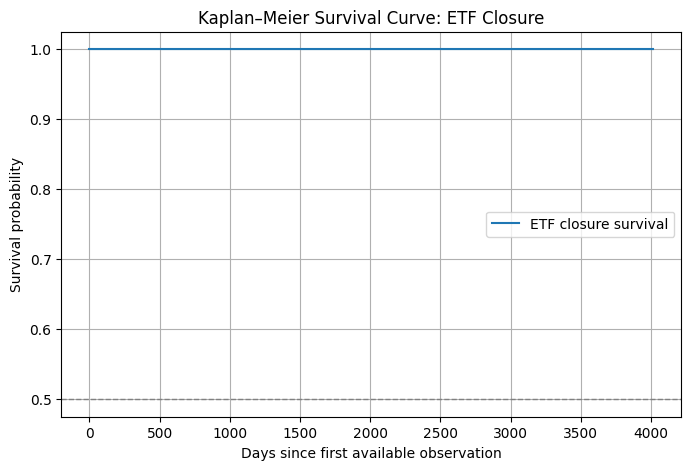

Median survival time not reached (curve never dropped below 0.5).


In [38]:
global_end = prices[date_col].max()

closure_rows = []

for etf in etf_cols:
    s = prices[[date_col, etf]].copy()
    s = s.dropna(subset=[etf]).reset_index(drop=True)
    
    first_date = s[date_col].min()
    last_date = s[date_col].max()
    duration = (last_date - first_date).days
    
    # Event proxy: series ends before overall dataset end
    event = int(last_date < global_end)
    
    # Simple ETF-level covariates
    returns = np.log(s[etf] / s[etf].shift(1)).dropna()
    avg_ret = returns.mean() if len(returns) > 0 else np.nan
    vol = returns.std() if len(returns) > 0 else np.nan
    
    closure_rows.append({
        'ETF': etf,
        'start_date': first_date,
        'end_date': last_date,
        'duration': max(duration, 1),
        'event': event,
        'avg_return': avg_ret,
        'volatility': vol
    })

closure_df = pd.DataFrame(closure_rows)
closure_df

# Kaplan–Meier for ETF closure with median line
print(closure_df[['ETF', 'duration', 'event']])
print("Total closure events:", closure_df['event'].sum())

plot_single_km_with_median(
    df=closure_df,
    duration_col='duration',
    event_col='event',
    label='ETF closure survival',
    title='Kaplan–Meier Survival Curve: ETF Closure',
    xlabel='Days since first available observation',
    ylabel='Survival probability'
)


# Hazard Plot for closure


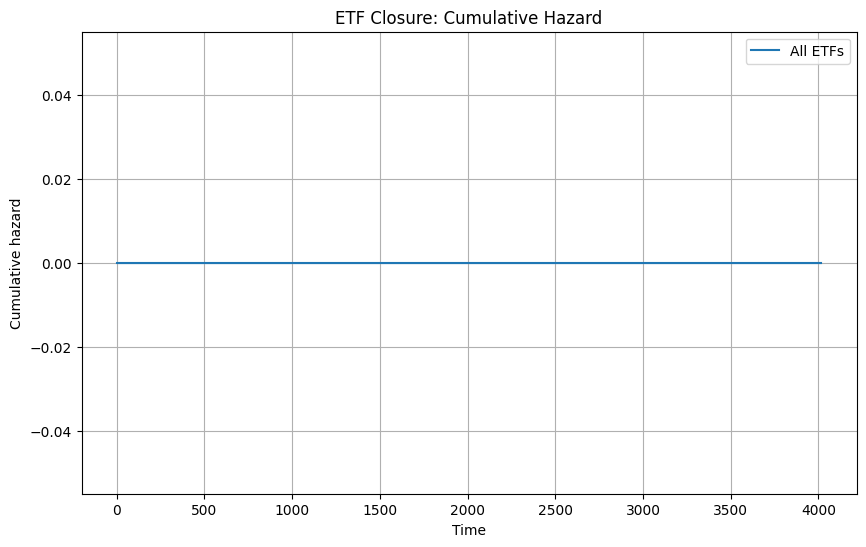

No stable smoothed hazard curves available for ETF Closure.


<Figure size 1000x600 with 0 Axes>

In [39]:
# Hazard / cumulative hazard for closure
# With only 4 ETFs, smoothed hazard may be unavailable or unstable.
closure_hazard_df = closure_df.copy()
closure_hazard_df['group'] = 'All ETFs'

plot_hazard_and_cumhaz_by_group(
    df=closure_hazard_df,
    duration_col='duration',
    event_col='event',
    group_col='group',
    title_prefix='ETF Closure',
    bandwidth=20
)

## Cox model for ETF closure

Because there are only 4 ETFs, this model may be unstable or not estimable.  
We still try it for completeness.

In [40]:
closure_cox = closure_df[['duration', 'event', 'avg_return', 'volatility']].dropna().copy()

if closure_cox['event'].sum() < 2 or len(closure_cox) < 4:
    print("Too few usable observations/events for a meaningful Cox model on ETF closure.")
    print(closure_cox)
else:
    try:
        cph_closure = CoxPHFitter()
        cph_closure.fit(closure_cox, duration_col='duration', event_col='event')
        cph_closure.print_summary()
    except ConvergenceError as e:
        print("Cox model failed to converge for closure event.")
        print(str(e))

Too few usable observations/events for a meaningful Cox model on ETF closure.
   duration  event  avg_return  volatility
0      4016      0    0.000501    0.011232
1      4016      0    0.000676    0.013868
2      4016      0    0.000450    0.009295
3      4016      0    0.000504    0.011283


# Part 2 — Event definition: Time to reach previous maximum point

## Event definition

We define a **drawdown-recovery episode** as follows:

- Track the running maximum price.
- When price drops below that running maximum, a drawdown starts.
- The event occurs when price first recovers back to at least that previous maximum.
- If recovery never happens before the sample ends, the episode is censored.

This gives multiple survival episodes per ETF, which makes Kaplan–Meier and Cox analysis much more meaningful.

Recovery episodes shape: (634, 8)


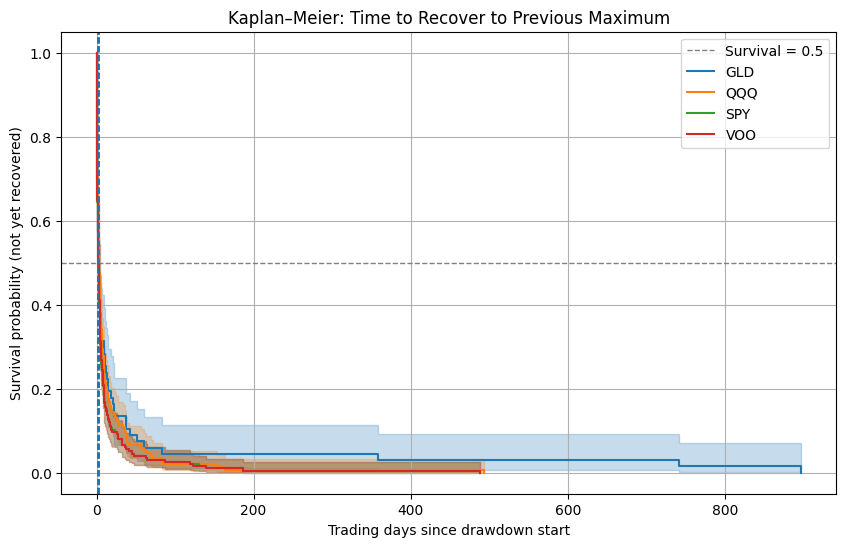

Median survival times:
  GLD: 3.00
  QQQ: 3.00
  SPY: 2.00
  VOO: 2.00


In [41]:
def build_recovery_episodes(df_etf, etf_name):
    """
    Build episodes for 'time to reach previous maximum point'.
    Each episode begins when price falls below the current running max,
    and ends when the price recovers to that max, or is censored at the end.
    """
    g = df_etf[[date_col, 'AdjClose', 'log_return', 'roll_vol_21', 'roll_mean_21']].dropna(subset=['AdjClose']).copy()
    g = g.sort_values(date_col).reset_index(drop=True)
    
    episodes = []
    running_max = -np.inf
    in_drawdown = False
    
    start_idx = None
    peak_price = None
    
    for i in range(len(g)):
        px = g.loc[i, 'AdjClose']
        
        if px >= running_max:
            running_max = px
            if in_drawdown:
                # Recovery event occurred
                duration = i - start_idx
                start_price = g.loc[start_idx, 'AdjClose']
                depth = (peak_price - start_price) / peak_price if peak_price > 0 else np.nan
                
                episodes.append({
                    'ETF': etf_name,
                    'start_date': g.loc[start_idx, date_col],
                    'end_date': g.loc[i, date_col],
                    'duration': max(duration, 1),
                    'event': 1,
                    'start_drawdown_depth': depth,
                    'roll_vol_21': g.loc[start_idx, 'roll_vol_21'],
                    'roll_mean_21': g.loc[start_idx, 'roll_mean_21']
                })
                in_drawdown = False
                start_idx = None
                peak_price = None
        else:
            if not in_drawdown:
                # Enter drawdown
                in_drawdown = True
                start_idx = i
                peak_price = running_max
    
    # If still in drawdown at the end, censor
    if in_drawdown and start_idx is not None:
        duration = len(g) - 1 - start_idx
        start_price = g.loc[start_idx, 'AdjClose']
        depth = (peak_price - start_price) / peak_price if peak_price > 0 else np.nan
        
        episodes.append({
            'ETF': etf_name,
            'start_date': g.loc[start_idx, date_col],
            'end_date': g.loc[len(g)-1, date_col],
            'duration': max(duration, 1),
            'event': 0,
            'start_drawdown_depth': depth,
            'roll_vol_21': g.loc[start_idx, 'roll_vol_21'],
            'roll_mean_21': g.loc[start_idx, 'roll_mean_21']
        })
    
    return pd.DataFrame(episodes)


recovery_episode_list = []

for etf in etf_cols:
    df_etf = long_feat[long_feat['ETF'] == etf].copy()
    ep = build_recovery_episodes(df_etf, etf)
    recovery_episode_list.append(ep)

recovery_df = pd.concat(recovery_episode_list, ignore_index=True)
print("Recovery episodes shape:", recovery_df.shape)
recovery_df.head(10)

plot_grouped_km_with_medians(
    df=recovery_df,
    duration_col='duration',
    event_col='event',
    group_col='ETF',
    title='Kaplan–Meier: Time to Recover to Previous Maximum',
    xlabel='Trading days since drawdown start',
    ylabel='Survival probability (not yet recovered)'
)

# Hazard plot for recovery

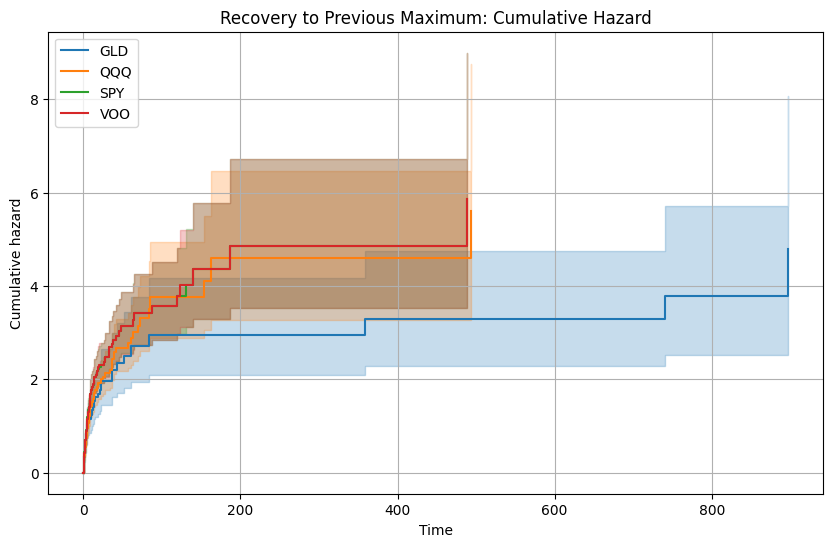

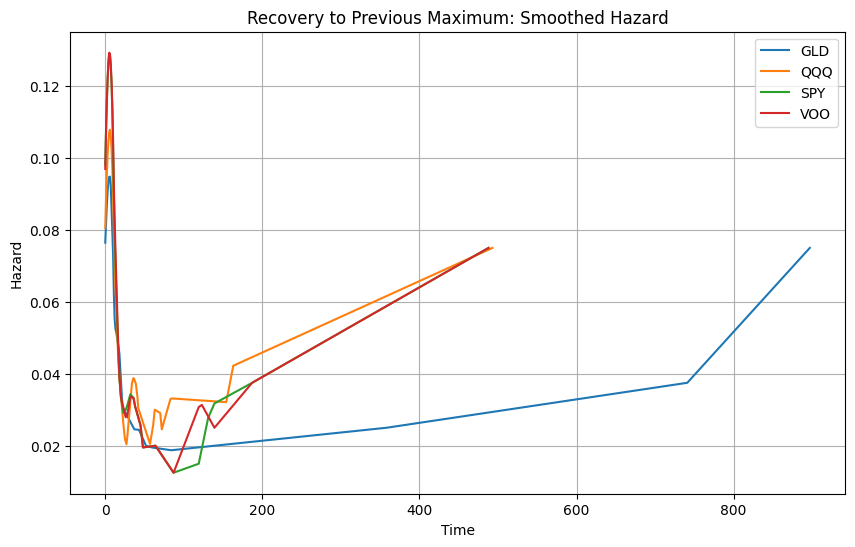

In [42]:
plot_hazard_and_cumhaz_by_group(
    df=recovery_df,
    duration_col='duration',
    event_col='event',
    group_col='ETF',
    title_prefix='Recovery to Previous Maximum',
    bandwidth=10
)

## Cox model for recovery event

Interpretation:
- A **higher hazard** means **faster recovery**
- A **lower hazard** means **slower recovery**

In [43]:
recovery_cox = recovery_df[['duration', 'event', 'start_drawdown_depth', 'roll_vol_21', 'roll_mean_21']].dropna().copy()

# Standardize covariates for stability
cov_cols = ['start_drawdown_depth', 'roll_vol_21', 'roll_mean_21']
scaler = StandardScaler()
recovery_cox[cov_cols] = scaler.fit_transform(recovery_cox[cov_cols])

print("Number of recovery episodes:", len(recovery_cox))
print("Number of recovery events:", recovery_cox['event'].sum())

if recovery_cox['event'].sum() < 5:
    print("Too few events for a reliable Cox model.")
else:
    cph_recovery = CoxPHFitter()
    cph_recovery.fit(recovery_cox, duration_col='duration', event_col='event')
    cph_recovery.print_summary()

Number of recovery episodes: 622
Number of recovery events: 618


<lifelines.CoxPHFitter: fitted with 622 total observations, 4 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 622
number of events observed = 618
   partial log-likelihood = -3338.95
         time fit was run = 2026-04-23 02:32:01 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
start_drawdown_depth -0.31      0.73      0.06           -0.42           -0.20                0.66                0.82
roll_vol_21          -0.01      0.99      0.04           -0.10            0.08                0.91                1.08
roll_mean_21          0.08      1.08      0.04            0.00            0.16                1.00                1.18

                      cmp to     z      p  -log2(p)
covariate                                          
start_drawdown_depth    0.00 -5.54 <0.005     24.94
roll_vol_21             0.00 -0.16   0.87      0.20
roll_mean_21            0.00  1.97   0.05      4.35
---
Concordance = 0.64
Partial AIC = 6683.91
log-likelihood ratio test = 47.52 on 3 df
-log2(p) of ll-ratio test = 31.79

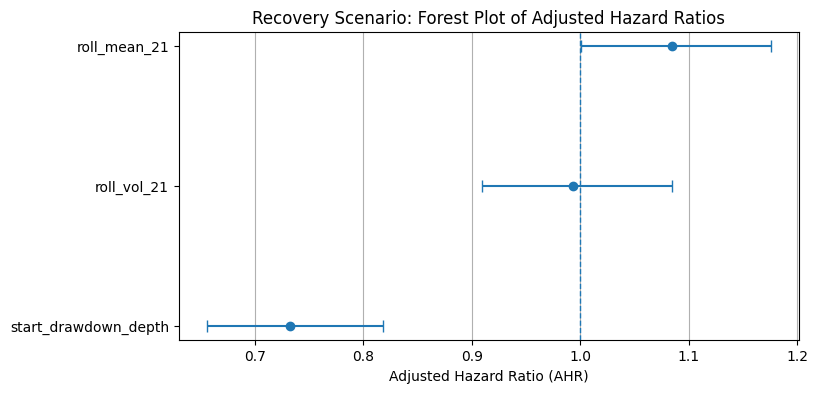

                                  variable       ahr     lower     upper  \
covariate                                                                  
start_drawdown_depth  start_drawdown_depth  0.732511  0.656073  0.817855   
roll_vol_21                    roll_vol_21  0.992859  0.909239  1.084169   
roll_mean_21                  roll_mean_21  1.084358  1.000378  1.175387   

                                 p  
covariate                           
start_drawdown_depth  3.096869e-08  
roll_vol_21           8.731562e-01  
roll_mean_21          4.893423e-02  


In [44]:
if 'cph_recovery' in globals():
    forest_recovery = make_forest_plot_from_cph(
        cph_recovery,
        title='Recovery Scenario: Forest Plot of Adjusted Hazard Ratios'
    )
    print(forest_recovery)

# Part 3 — Event definition: First time actual loss exceeds the VaR estimate

## Event definition

We first estimate a rolling historical VaR from past losses.

For each ETF and each eligible start point:
- begin an episode on day `t`,
- observe future days,
- event occurs at the **first future day** where actual loss > VaR estimate,
- censor if no exceedance occurs before the allowed horizon ends.

To avoid extremely long overlapping episodes, we cap the follow-up window.

VaR breach episodes shape: (10808, 10)


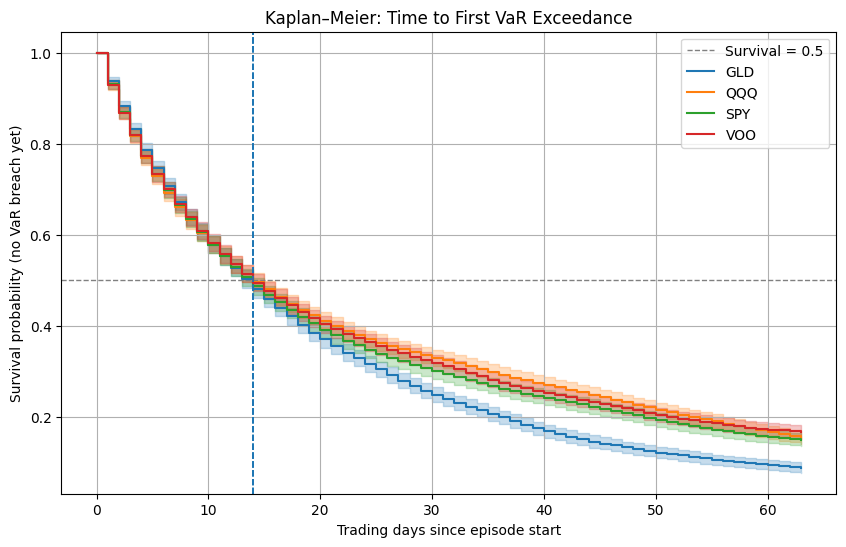

Median survival times:
  GLD: 14.00
  QQQ: 14.00
  SPY: 14.00
  VOO: 14.00


In [45]:
MAX_HORIZON = 63   # follow each episode for up to 63 trading days

def build_var_breach_episodes(df_etf, etf_name, max_horizon=63):
    """
    Build episodes where the event is the first time actual loss exceeds VaR.
    Each valid day t starts an episode, and we look forward until first breach or censoring.
    """
    g = df_etf[[date_col, 'AdjClose', 'log_return', 'loss', 'roll_vol_21', 'roll_mean_21', 'VaR_95']].copy()
    g = g.sort_values(date_col).reset_index(drop=True)
    
    # Need valid loss and VaR to start an episode
    episodes = []
    
    for start_idx in range(len(g) - 1):
        if pd.isna(g.loc[start_idx, 'VaR_95']) or pd.isna(g.loc[start_idx, 'roll_vol_21']) or pd.isna(g.loc[start_idx, 'roll_mean_21']):
            continue
        
        event = 0
        duration = None
        end_idx = min(start_idx + max_horizon, len(g) - 1)
        
        for j in range(start_idx + 1, end_idx + 1):
            if pd.isna(g.loc[j, 'loss']):
                continue
            if g.loc[j, 'loss'] > g.loc[start_idx, 'VaR_95']:
                event = 1
                duration = j - start_idx
                breach_loss = g.loc[j, 'loss']
                break
        
        if duration is None:
            duration = end_idx - start_idx
            breach_loss = np.nan
        
        episodes.append({
            'ETF': etf_name,
            'start_date': g.loc[start_idx, date_col],
            'end_date': g.loc[start_idx + duration, date_col] if (start_idx + duration) < len(g) else g.loc[end_idx, date_col],
            'duration': max(duration, 1),
            'event': event,
            'VaR_95_start': g.loc[start_idx, 'VaR_95'],
            'roll_vol_21': g.loc[start_idx, 'roll_vol_21'],
            'roll_mean_21': g.loc[start_idx, 'roll_mean_21'],
            'start_loss': g.loc[start_idx, 'loss'],
            'breach_loss': breach_loss
        })
    
    return pd.DataFrame(episodes)


var_episode_list = []

for etf in etf_cols:
    df_etf = long_feat[long_feat['ETF'] == etf].copy()
    ep = build_var_breach_episodes(df_etf, etf, max_horizon=MAX_HORIZON)
    var_episode_list.append(ep)

var_df = pd.concat(var_episode_list, ignore_index=True)
print("VaR breach episodes shape:", var_df.shape)
var_df.head(10)

plot_grouped_km_with_medians(
    df=var_df,
    duration_col='duration',
    event_col='event',
    group_col='ETF',
    title='Kaplan–Meier: Time to First VaR Exceedance',
    xlabel='Trading days since episode start',
    ylabel='Survival probability (no VaR breach yet)'
)

# Hazard Plot

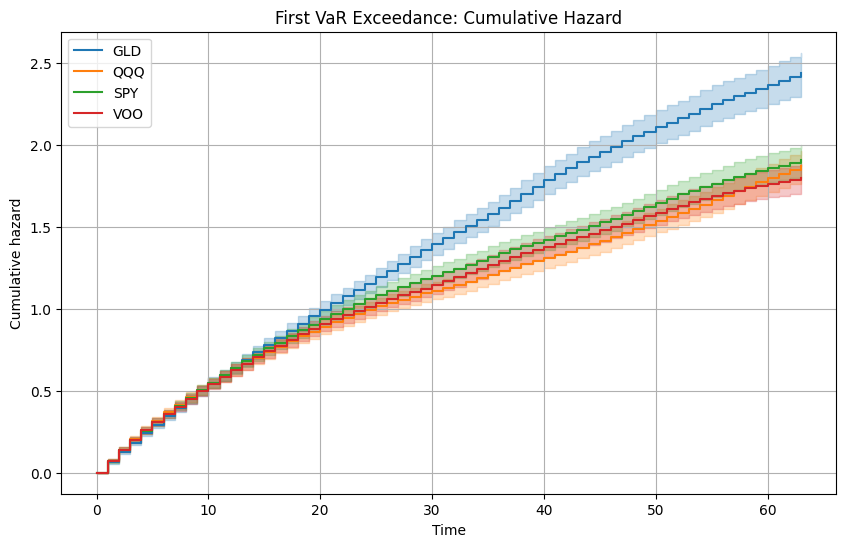

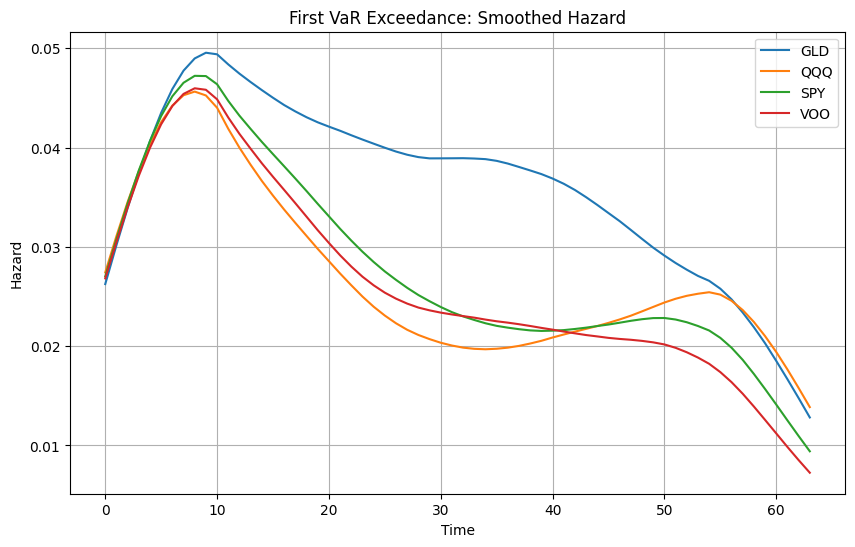

In [46]:
plot_hazard_and_cumhaz_by_group(
    df=var_df,
    duration_col='duration',
    event_col='event',
    group_col='ETF',
    title_prefix='First VaR Exceedance',
    bandwidth=10
)

In [47]:
run_multigroup_logrank(
    df=var_df,
    duration_col='duration',
    event_col='event',
    group_col='ETF',
    title='VaR exceedance scenario: log-rank test across ETFs'
)

=== VaR exceedance scenario: log-rank test across ETFs ===
   test_statistic             p  -log2(p)
0       54.293709  9.713472e-12  36.58315


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          54.29 <0.005     36.58

## Cox model for VaR exceedance

Interpretation:
- A **higher hazard** means **faster occurrence of a VaR breach**
- A **lower hazard** means **longer survival without a VaR breach**

In [48]:
var_cox = var_df[['duration', 'event', 'VaR_95_start', 'roll_vol_21', 'roll_mean_21', 'start_loss']].dropna().copy()

cov_cols = ['VaR_95_start', 'roll_vol_21', 'roll_mean_21', 'start_loss']
scaler = StandardScaler()
var_cox[cov_cols] = scaler.fit_transform(var_cox[cov_cols])

print("Number of VaR episodes:", len(var_cox))
print("Number of VaR breach events:", var_cox['event'].sum())

if var_cox['event'].sum() < 5:
    print("Too few events for a reliable Cox model.")
else:
    cph_var = CoxPHFitter()
    cph_var.fit(var_cox, duration_col='duration', event_col='event')
    cph_var.print_summary()

Number of VaR episodes: 10808
Number of VaR breach events: 9247


<lifelines.CoxPHFitter: fitted with 10808 total observations, 1561 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 10808
number of events observed = 9247
   partial log-likelihood = -78652.59
         time fit was run = 2026-04-23 02:32:06 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
VaR_95_start -0.75      0.47      0.02           -0.79           -0.71                0.45                0.49
roll_vol_21   0.37      1.45      0.02            0.33            0.40                1.40                1.50
roll_mean_21  0.05      1.05      0.01            0.03            0.08                1.03                1.08
start_loss    0.08      1.08      0.01            0.06            0.10                1.06                1.11

              cmp to      z      p  -log2(p)
covariate                                   
VaR_95_start    0.00 -36.74 <0.005    979.39
roll_vol_21     0.00  21.32 <0.005    332.73
roll_mean_21    0.00   3.91 <0.005     13.38
start_loss      0.00   6.48 <0.005     33.33
---
Concordance = 0.64
Partial AIC = 157313.18
log-likelihood ratio test = 1802.04 on 4 df
-log2(p) of ll-ratio test = inf

## Summary tables

These help compare the three event definitions.

In [49]:
print("=== Closure event summary ===")
print(closure_df[['ETF', 'duration', 'event']])

print("\n=== Recovery event summary ===")
print(recovery_df.groupby('ETF').agg(
    n_episodes=('event', 'size'),
    n_events=('event', 'sum'),
    median_duration=('duration', 'median')
).reset_index())

print("\n=== VaR exceedance event summary ===")
print(var_df.groupby('ETF').agg(
    n_episodes=('event', 'size'),
    n_events=('event', 'sum'),
    median_duration=('duration', 'median')
).reset_index())

=== Closure event summary ===
   ETF  duration  event
0  SPY      4016      0
1  QQQ      4016      0
2  GLD      4016      0
3  VOO      4016      0

=== Recovery event summary ===
   ETF  n_episodes  n_events  median_duration
0  GLD          69        68              3.0
1  QQQ         166       165              3.0
2  SPY         200       199              2.0
3  VOO         199       198              2.0

=== VaR exceedance event summary ===
   ETF  n_episodes  n_events  median_duration
0  GLD        2702      2464             14.0
1  QQQ        2702      2267             14.0
2  SPY        2702      2281             14.0
3  VOO        2702      2235             14.0


## Optional interpretation guide

- **Closure event**
  - Survival = ETF remains active / still observed
  - Weakest analysis here because only 4 ETFs and probably very few closures

- **Recovery to previous maximum**
  - Survival = ETF has not yet recovered from drawdown
  - Good for comparing resilience and rebound speed

- **First VaR exceedance**
  - Survival = ETF has not yet experienced a loss larger than its VaR estimate
  - Good for tail-risk and stress-event timing

In [ ]:
# Save prepared datasets if needed
closure_df.to_csv('/kaggle/working/closure_survival_dataset.csv', index=False)
recovery_df.to_csv('/kaggle/working/recovery_survival_dataset.csv', index=False)
var_df.to_csv('/kaggle/working/var_breach_survival_dataset.csv', index=False)

print("Saved:")
print("/kaggle/working/closure_survival_dataset.csv")
print("/kaggle/working/recovery_survival_dataset.csv")
print("/kaggle/working/var_breach_survival_dataset.csv")